In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import (
    browse_swot_250,
    add_mask_inside_swot,
    build_swath_polygon,
    swot_interp_grad_one,
    partition_swot_interp_grad,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

/Users/mdemol/code/pynsitu/pynsitu/__init__.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  hour = Timedelta("1H")


____
# Colocalization definition
- select the nearest in time of a SWOT image drifter point 
- import SWOT data at this point :
    - for SWOT-250m interpolate on a cartesian grid, compute gradient on this grid, interpolate at the drifter position
    - for SWOT-2km compute gradient, interpolate at the drifter position
    - for SWOT-nadir, select nearest nadir point, comute gradient at this point

if True:
    from dask.distributed import Client
    from dask_jobqueue import PBSCluster
    from dask import config
    #config.set({"distributed.comm.timeouts.connect": "200s"})
    cluster = PBSCluster(cores=28, processes = 28, walltime='01:00:00')
    #cluster = PBSCluster(cores=20, processes=20, walltime='02:00:00')#8
    w = cluster.scale(jobs=1)
else:
    from dask.distributed import Client, LocalCluster
    cluster = LocalCluster(n_workers=16)

client = Client(cluster)
client

In [118]:
cluster.close()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask_jobqueue/core.py:237: FutureWarning: extra has been renamed to worker_extra_args. You are still using it (even if only set to []; please also check config files). If you did not set worker_extra_args yet, extra will be respected for now, but it will be removed in a future release. If you already set worker_extra_args, extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/home1/datahome/mdemol/

_______
# Data

In [2]:
dfs = browse_swot_250().reset_index()
drifters_sources = "all_med_variational_10min_v0.nc"
df = pd.read_csv(
    os.path.join(zarr_dir, "drifters_" + drifters_sources.replace(".nc", ".csv"))
)

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_2202/2062596265.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))


__________
# SWOT

In [3]:
ggrad_variables = [
    "cvl_mean_dynamic_topography_cnes_cls_22",
    "cvl_mean_sea_surface_cnes_22_hybrid",
    "cvl_ocean_tide_fes_2022",
    "cvl_ssha_reference",
    "duacs_ssha_karin_2_calibrated",
    "duacs_ssha_karin_2_filtered",
]

variables = [
    "duacs_relative_vorticity",
    "duacs_speed_meridional",
    "duacs_speed_meridional_abs",
    "duacs_speed_zonal",
    "duacs_speed_zonal_abs",
    "cvl_swh_model",
]

In [4]:
# get grid orientation and metrics
def add_grid_metrics(ds):
    """add grid spatial metrics"""

    geod = Geod(ellps="WGS84")

    lon, lat = ds.longitude, ds.latitude
    dims = lon.dims

    # d/dx where x is cross-track
    az12, az21, dx = geod.inv(
        lon,
        lat,
        lon.shift(num_pixels=-1),
        lat.shift(num_pixels=-1),
    )

    ds = ds.assign_coords(dx=(dims, dx), phi=(dims, az12 * np.pi / 180))

    ds["dx"] = ds["dx"].ffill("num_pixels").where(ds["duacs_editing_flag"] < 5)

    # phi is cross-track direction from north
    ds["phi"] = ds["phi"].ffill("num_pixels").where(ds["duacs_editing_flag"] < 5)

    # d/dy where y is along-track

    az12, az21, dy = geod.inv(
        lon,
        lat,
        lon.shift(num_lines=-1),
        lat.shift(num_lines=-1),
    )

    ds = ds.assign_coords(dy=(dims, dy))

    ds["dy"] = ds["dy"].ffill("num_lines").where(ds["duacs_editing_flag"] < 5)

    return ds

In [5]:
cycle = 500
swath = 3

dss = xr.open_dataset(
    dfs.where((dfs.pass_number == swath) & (dfs.cycle_number == cycle))
    .dropna()
    .file.values[0]
)
dss = add_grid_metrics(dss)

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


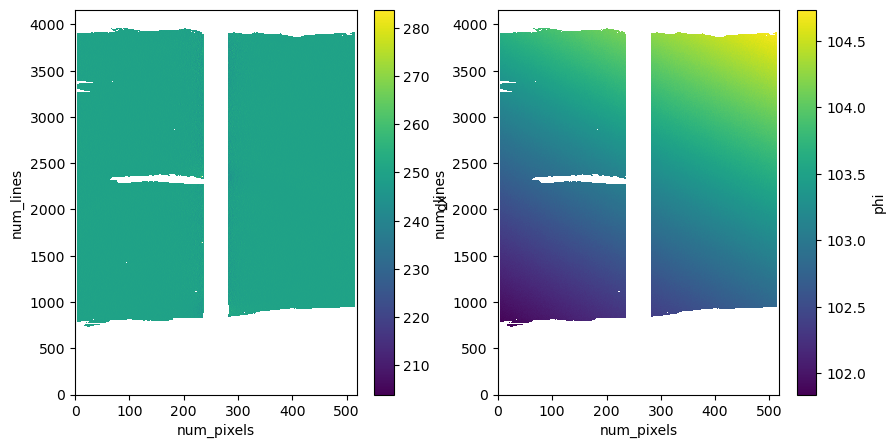

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
dss["dx"].plot(ax=axes[0])
(dss["phi"] * 180 / np.pi).plot(ax=axes[1])

In [17]:
dss["dx"].mean().compute(), dss["dx"].std().compute()

(<xarray.DataArray 'dx' ()> Size: 8B
 array(249.88069072),
 <xarray.DataArray 'dx' ()> Size: 8B
 array(0.55453346))

In [18]:
dss["dy"].mean().compute(), dss["dy"].std().compute()

(<xarray.DataArray 'dy' ()> Size: 8B
 array(238.37792942),
 <xarray.DataArray 'dy' ()> Size: 8B
 array(1.13034736))

# Compute gradient

## Naive way

In [22]:
# Compute ggrad with "naive" approach, noise will have an impact
g = 9.80665
dx = dss.dx.mean()  # meters
dy = dss.dy.mean()
dss_ggrad = dss[ggrad_variables]
dss_ggradx = (g * dss_ggrad.differentiate("num_pixels") / dx).rename(
    {v: "ggradx_" + v for v in dss_ggrad}
)
dss_ggrady = (g * dss_ggrad.differentiate("num_lines") / dy).rename(
    {v: "ggrady_" + v for v in dss_ggrad}
)
dss_naive = xr.merge([dss, dss_ggradx, dss_ggrady])

## Gaussian gradient

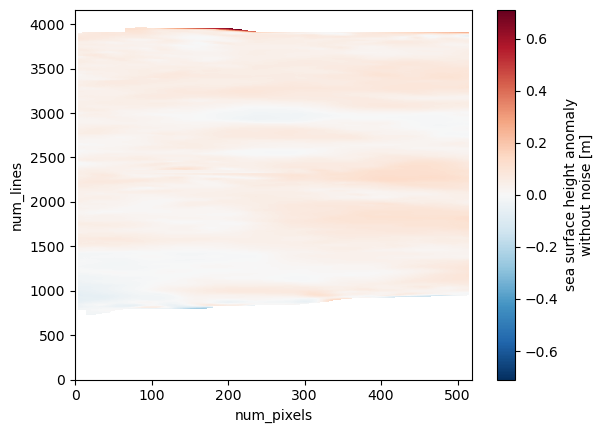

In [30]:
dss_ggrad.duacs_ssha_karin_2_filtered.interpolate_na(dim="num_pixels").interpolate_na(
    dim="num_lines"
).plot()

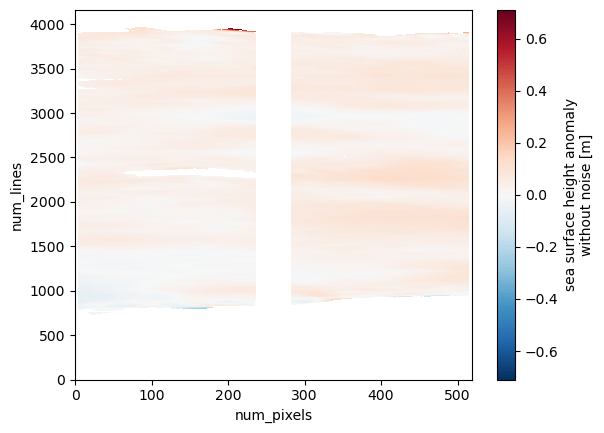

In [28]:
dss_ggrad.duacs_ssha_karin_2_filtered.plot()

In [77]:
# gaussian derivative
from scipy.ndimage import gaussian_filter


def gradient_gauss(dss, cutoff=1e3, **kwargs):
    dx = float(dss.dx.mean())
    dy = float(dss.dy.mean())

    dss_ggradx = xr.Dataset()
    dss_ggrady = xr.Dataset()

    for v in dss:
        da = (
            dss[v].interpolate_na(dim="num_pixels").interpolate_na(dim="num_lines")
        )  # prevent nan to spread

        # cross-track
        i = da.get_axis_num("num_pixels")
        order = [0, 0]
        order[i] = 1
        dss_ggradx["ggradx_" + v] = g * (
            xr.DataArray(
                gaussian_filter(da, sigma=cutoff / dx, order=order, **kwargs),
                dims=da.dims,
            )
            / dx
        ).where(~dss[v].isnull())
        # da_dx = da_dx.where(da)

        # along-track
        i = da.get_axis_num("num_lines")
        order = [0, 0]
        order[i] = 1
        dss_ggrady["ggrady_" + v] = g * (
            xr.DataArray(
                gaussian_filter(da, sigma=cutoff / dy, order=order, **kwargs),
                dims=da.dims,
            )
            / dy
        ).where(~dss[v].isnull())

    return dss_ggradx, dss_ggrady


dss_ggradx, dss_ggrady = gradient_gauss(dss_ggrad)
dss_gauss = xr.merge([dss, dss_ggradx, dss_ggrady])
# da_dx_gaussb, da_dy_gaussb = gradient_gauss(da, cutoff=5e3, truncate=2.)

Text(0.5, 1.0, 'Gaussian-Naive')

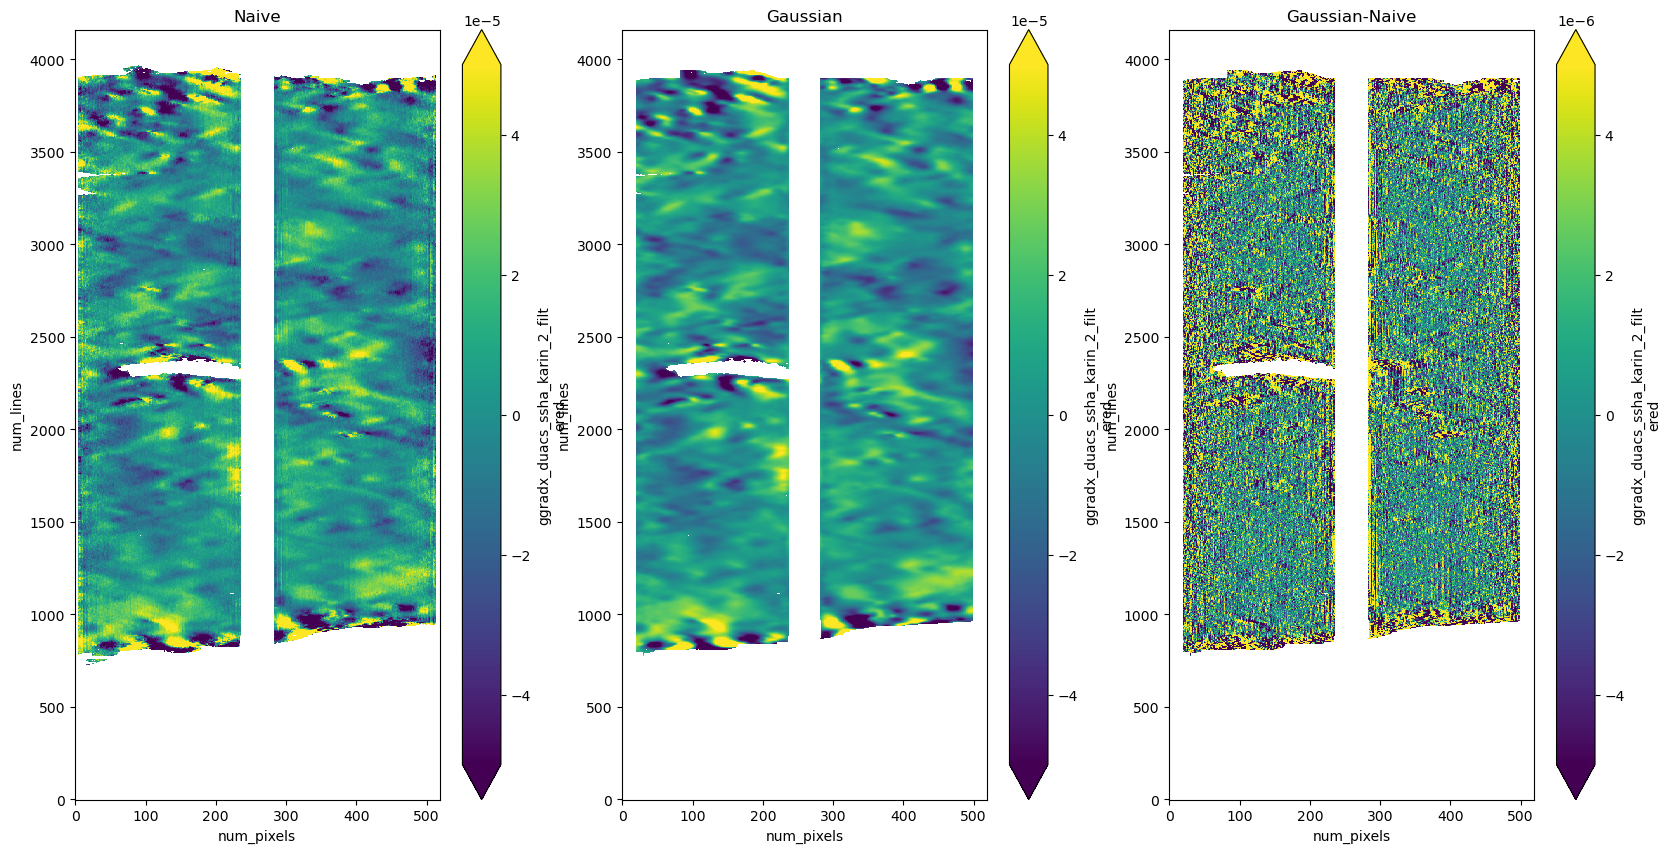

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
dss_naive.ggradx_duacs_ssha_karin_2_filtered.plot(ax=axes[0], vmin=-5e-5, vmax=5e-5)
axes[0].set_title("Naive")
dss_gauss.ggradx_duacs_ssha_karin_2_filtered.plot(ax=axes[1], vmin=-5e-5, vmax=5e-5)
axes[1].set_title("Gaussian")
(
    dss_gauss.ggradx_duacs_ssha_karin_2_filtered
    - dss_naive.ggradx_duacs_ssha_karin_2_filtered
).plot(ax=axes[2], vmin=-5e-6, vmax=5e-6)
axes[2].set_title("Gaussian-Naive")

In [4]:
# FOR TEST
df_ = df.iloc[0:100]
from dask.dataframe import from_pandas

ddf_ = from_pandas(df_, chunksize=10)

In [5]:
df0_ = df.iloc[0:4]

In [6]:
from dask.dataframe import from_pandas

ddf = from_pandas(df, chunksize=10)

In [11]:
ddf

,Unnamed: 0,pass_number,drifter_id,datetime,x,y,drifter_type,cruise_id,lonc,latc,longitude,latitude,velocity_east,velocity_north,velocity,acceleration_east,acceleration_north,acceleration,X,gap_mask,gaps,inside_left,inside_right,time_to_swot,cycle_number,row_number
npartitions=298,,,,,,,,,,,,,,,,,,,,,,,,,,
0,int64,int64,object,object,float64,float64,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,int64,int64
10,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2970,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2977,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


_______
# SWOT 250m

In [7]:
df_meta = partition_swot_interp_grad(df0_)

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:593: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=43,44 m=1680 fp=0.000001 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:593: RuntimeWarning: No more knots 

0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:593: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=32,32 m=873 fp=333.502744 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:593: RuntimeWarning: No more knots

1


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:593: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=43,43 m=1680 fp=270.277992 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:593: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=44,43 m=1680 fp=0.000000 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:593: RuntimeWarning: No more knots can be added because the number 

2


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:593: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=43,43 m=1679 fp=0.000016 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))


3


In [8]:
ddf_done = ddf.map_partitions(partition_swot_interp_grad, meta=df_meta)
ddf_done = ddf_done.compute()

In [20]:
df.drop(columns="Unnamed: 0").rename(columns={"row_number": "coloc_number"}).set_index(
    "coloc_number"
).to_csv(os.path.join(zarr_dir, "drifters_" + drifters_sources.replace(".nc", ".csv")))

In [15]:
ddf_done

,duacs_relative_vorticity,duacs_speed_meridional,duacs_speed_meridional_abs,duacs_speed_zonal,duacs_speed_zonal_abs,cvl_swh_model,ggradx_cvl_mean_dynamic_topography_cnes_cls_22,ggradx_cvl_mean_sea_surface_cnes_22_hybrid,ggradx_cvl_ocean_tide_fes_2022,ggradx_cvl_ssha_reference,ggradx_duacs_ssha_karin_2_calibrated,ggradx_duacs_ssha_karin_2_filtered,ggrady_cvl_mean_dynamic_topography_cnes_cls_22,ggrady_cvl_mean_sea_surface_cnes_22_hybrid,ggrady_cvl_ocean_tide_fes_2022,ggrady_cvl_ssha_reference,ggrady_duacs_ssha_karin_2_calibrated,ggrady_duacs_ssha_karin_2_filtered
0,-3.445889,-2.348813e-01,-2.592586e-01,0.198686,0.214902,2.977000,-2.961265e-06,0.000385,-1.282359e-06,0.000559,5.661758e-04,-0.000021,2.367733e-06,0.000257,-1.569323e-06,-0.000256,-3.852288e-04,0.000013
1,77.162093,4.172567e-01,1.784129e-01,-1.814637,-2.083291,2.708282,5.221011e-04,-0.186930,-5.060671e-05,0.023912,2.349423e-02,0.000014,-3.339792e-03,-0.201419,-1.000968e-04,-0.032887,-3.103318e-02,-0.000169
2,5.138697,-3.300897e-01,-3.214274e-01,0.050802,-0.189893,2.701219,2.383201e-05,0.000383,7.182161e-08,-0.037293,-8.053744e-04,-0.000007,7.250831e-06,0.000141,-8.612633e-08,-0.411419,-6.741039e-04,0.000030
3,2.437419,-7.326040e-02,-7.930297e-02,-0.074279,-0.070914,3.088493,5.367451e-08,0.000221,-1.985225e-07,-0.000809,-8.339717e-04,0.000010,1.323148e-08,0.000074,4.170518e-07,0.001469,1.339673e-03,0.000012
4,-9.202621,-8.469274e-02,-9.086611e-02,-0.452736,-0.420802,2.555307,-2.229602e-07,0.000025,1.038895e-08,0.000195,2.000303e-04,0.000038,-3.499389e-08,0.000090,-9.251543e-09,0.000583,4.435307e-04,0.000025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2973,-3.744464,5.193506e-01,1.387812e-01,-22437.701880,-0.763180,0.400956,-4.921993e-03,0.000391,3.485799e-04,9.762740,-2.822242e-02,0.000007,-1.463856e-04,-0.000314,7.054781e-05,5.971285,-2.033623e-02,-0.000045
2974,0.072564,1.291969e-01,7.395303e-02,-1.085196,0.195477,0.373024,3.030534e-03,-0.000297,1.722469e-02,-0.698094,1.699032e+00,-0.000299,-8.459723e-03,0.000069,3.564742e-02,1.917535,-2.200704e+00,-0.001184
2975,-5.288642,-4.681589e-01,-4.542539e-01,-0.056042,-0.092059,0.421087,5.363192e-06,0.000354,-7.511289e-07,-0.000600,7.584838e-04,0.000013,-1.849312e-06,0.000159,1.106608e-06,-0.000859,-5.700920e-04,0.000104
2976,-11.233609,6.041896e-03,4.434347e+02,-0.131226,-0.201682,0.555878,5.999787e-06,0.000172,1.195715e-05,0.000461,5.045044e+07,-0.000068,2.320879e-06,0.000291,6.048337e-06,0.000099,2.415108e+06,0.000435


In [22]:
df

,coloc_number,pass_number,drifter_id,datetime,x,y,drifter_type,cruise_id,lonc,latc,...,acceleration_east,acceleration_north,acceleration,X,gap_mask,gaps,inside_left,inside_right,time_to_swot,cycle_number
0,0,3,0-4351296,2023-04-01 23:40:00,8622.832328,21924.659043,CARTHE,C-SWOT,5.527754,42.057971,...,-1.516511e-05,-0.000023,0.000028,23559.369930,1.0,-207.0,0.0,1.0,0 days 00:02:32.696536,478
1,1,3,0-4388554,2023-04-02 01:10:00,-95054.703819,106548.021935,CARTHE,C-SWOT,6.413999,41.954212,...,-1.591731e-05,-0.000001,0.000016,142786.125714,1.0,-63.0,1.0,0.0,0 days 01:27:27.303464,478
2,2,3,0-4388557,2023-04-01 23:40:00,-178262.577692,87760.309380,CARTHE,C-SWOT,7.740748,42.111261,...,5.276845e-06,-0.000003,0.000006,198694.284035,1.0,218.0,0.0,1.0,0 days 00:02:32.696536,478
3,3,3,0-4388599,2023-04-01 23:40:00,-210162.459192,253256.839607,CARTHE,C-SWOT,7.317710,39.945366,...,-1.169734e-06,0.000003,0.000003,329100.723277,1.0,-290.0,1.0,0.0,0 days 00:02:32.696536,478
4,4,3,2,2023-04-01 23:40:00,-36246.759809,68490.243289,MELODI,C-SWOT,6.034560,40.946980,...,-8.218213e-06,-0.000010,0.000013,77490.264049,1.0,480.0,0.0,1.0,0 days 00:02:32.696536,478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2973,2973,16,300534060015760,2023-07-09 19:00:00,-148808.001876,-34321.844465,SVP,C-SWOT,4.113000,40.054600,...,1.350491e-05,0.000004,0.000014,152714.800952,1.0,0.0,1.0,0.0,0 days 00:03:38.131544384,577
2974,2974,16,300534060211000,2023-07-09 19:00:00,-84509.970300,-123730.668332,SVP,C-SWOT,2.769300,40.444300,...,4.783082e-07,0.000005,0.000005,149837.289638,1.0,0.0,0.0,1.0,0 days 00:03:38.131544384,577
2975,2975,16,300534060218400,2023-07-09 19:00:00,-270891.645929,-12388.407748,SVP,C-SWOT,4.825600,38.549400,...,-1.862255e-06,0.000018,0.000018,271174.771099,1.0,0.0,0.0,1.0,0 days 00:03:38.131544384,577
2976,2976,16,4694223,2023-07-09 22:40:00,-37905.401888,143751.119353,CARTHE,FAST-SWOT,2.002175,39.647955,...,5.472507e-06,0.000003,0.000006,148664.736261,1.0,168.0,0.0,1.0,0 days 03:43:38.131544384,577


In [24]:
ddf_done["coloc_number"] = np.arange(0, 2978)

In [25]:
ddf_done

,duacs_relative_vorticity,duacs_speed_meridional,duacs_speed_meridional_abs,duacs_speed_zonal,duacs_speed_zonal_abs,cvl_swh_model,ggradx_cvl_mean_dynamic_topography_cnes_cls_22,ggradx_cvl_mean_sea_surface_cnes_22_hybrid,ggradx_cvl_ocean_tide_fes_2022,ggradx_cvl_ssha_reference,ggradx_duacs_ssha_karin_2_calibrated,ggradx_duacs_ssha_karin_2_filtered,ggrady_cvl_mean_dynamic_topography_cnes_cls_22,ggrady_cvl_mean_sea_surface_cnes_22_hybrid,ggrady_cvl_ocean_tide_fes_2022,ggrady_cvl_ssha_reference,ggrady_duacs_ssha_karin_2_calibrated,ggrady_duacs_ssha_karin_2_filtered,coloc_number
0,-3.445889,-2.348813e-01,-2.592586e-01,0.198686,0.214902,2.977000,-2.961265e-06,0.000385,-1.282359e-06,0.000559,5.661758e-04,-0.000021,2.367733e-06,0.000257,-1.569323e-06,-0.000256,-3.852288e-04,0.000013,0
1,77.162093,4.172567e-01,1.784129e-01,-1.814637,-2.083291,2.708282,5.221011e-04,-0.186930,-5.060671e-05,0.023912,2.349423e-02,0.000014,-3.339792e-03,-0.201419,-1.000968e-04,-0.032887,-3.103318e-02,-0.000169,1
2,5.138697,-3.300897e-01,-3.214274e-01,0.050802,-0.189893,2.701219,2.383201e-05,0.000383,7.182161e-08,-0.037293,-8.053744e-04,-0.000007,7.250831e-06,0.000141,-8.612633e-08,-0.411419,-6.741039e-04,0.000030,2
3,2.437419,-7.326040e-02,-7.930297e-02,-0.074279,-0.070914,3.088493,5.367451e-08,0.000221,-1.985225e-07,-0.000809,-8.339717e-04,0.000010,1.323148e-08,0.000074,4.170518e-07,0.001469,1.339673e-03,0.000012,3
4,-9.202621,-8.469274e-02,-9.086611e-02,-0.452736,-0.420802,2.555307,-2.229602e-07,0.000025,1.038895e-08,0.000195,2.000303e-04,0.000038,-3.499389e-08,0.000090,-9.251543e-09,0.000583,4.435307e-04,0.000025,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2973,-3.744464,5.193506e-01,1.387812e-01,-22437.701880,-0.763180,0.400956,-4.921993e-03,0.000391,3.485799e-04,9.762740,-2.822242e-02,0.000007,-1.463856e-04,-0.000314,7.054781e-05,5.971285,-2.033623e-02,-0.000045,2973
2974,0.072564,1.291969e-01,7.395303e-02,-1.085196,0.195477,0.373024,3.030534e-03,-0.000297,1.722469e-02,-0.698094,1.699032e+00,-0.000299,-8.459723e-03,0.000069,3.564742e-02,1.917535,-2.200704e+00,-0.001184,2974
2975,-5.288642,-4.681589e-01,-4.542539e-01,-0.056042,-0.092059,0.421087,5.363192e-06,0.000354,-7.511289e-07,-0.000600,7.584838e-04,0.000013,-1.849312e-06,0.000159,1.106608e-06,-0.000859,-5.700920e-04,0.000104,2975
2976,-11.233609,6.041896e-03,4.434347e+02,-0.131226,-0.201682,0.555878,5.999787e-06,0.000172,1.195715e-05,0.000461,5.045044e+07,-0.000068,2.320879e-06,0.000291,6.048337e-06,0.000099,2.415108e+06,0.000435,2976


In [26]:
ddf_done.set_index("coloc_number").to_csv(os.path.join(zarr_dir, "DATA_MED_COLOC.csv"))

In [40]:
ddf_read = pd.read_csv(os.path.join(zarr_dir, "DATA_MED_COLOC.csv"))

In [41]:
ddf_read

,coloc_number,duacs_relative_vorticity,duacs_speed_meridional,duacs_speed_meridional_abs,duacs_speed_zonal,duacs_speed_zonal_abs,cvl_swh_model,ggradx_cvl_mean_dynamic_topography_cnes_cls_22,ggradx_cvl_mean_sea_surface_cnes_22_hybrid,ggradx_cvl_ocean_tide_fes_2022,ggradx_cvl_ssha_reference,ggradx_duacs_ssha_karin_2_calibrated,ggradx_duacs_ssha_karin_2_filtered,ggrady_cvl_mean_dynamic_topography_cnes_cls_22,ggrady_cvl_mean_sea_surface_cnes_22_hybrid,ggrady_cvl_ocean_tide_fes_2022,ggrady_cvl_ssha_reference,ggrady_duacs_ssha_karin_2_calibrated,ggrady_duacs_ssha_karin_2_filtered
0,0,-3.445889,-2.348813e-01,-2.592586e-01,0.198686,0.214902,2.977000,-2.961265e-06,0.000385,-1.282359e-06,0.000559,5.661758e-04,-0.000021,2.367733e-06,0.000257,-1.569323e-06,-0.000256,-3.852288e-04,0.000013
1,1,77.162093,4.172567e-01,1.784129e-01,-1.814637,-2.083291,2.708282,5.221011e-04,-0.186930,-5.060671e-05,0.023912,2.349423e-02,0.000014,-3.339792e-03,-0.201419,-1.000968e-04,-0.032887,-3.103318e-02,-0.000169
2,2,5.138697,-3.300897e-01,-3.214274e-01,0.050802,-0.189893,2.701219,2.383201e-05,0.000383,7.182161e-08,-0.037293,-8.053744e-04,-0.000007,7.250831e-06,0.000141,-8.612633e-08,-0.411419,-6.741039e-04,0.000030
3,3,2.437419,-7.326040e-02,-7.930297e-02,-0.074279,-0.070914,3.088493,5.367451e-08,0.000221,-1.985225e-07,-0.000809,-8.339717e-04,0.000010,1.323148e-08,0.000074,4.170518e-07,0.001469,1.339673e-03,0.000012
4,4,-9.202621,-8.469274e-02,-9.086611e-02,-0.452736,-0.420802,2.555307,-2.229602e-07,0.000025,1.038895e-08,0.000195,2.000303e-04,0.000038,-3.499389e-08,0.000090,-9.251543e-09,0.000583,4.435307e-04,0.000025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2973,2973,-3.744464,5.193506e-01,1.387812e-01,-22437.701880,-0.763180,0.400956,-4.921993e-03,0.000391,3.485799e-04,9.762740,-2.822242e-02,0.000007,-1.463856e-04,-0.000314,7.054781e-05,5.971285,-2.033623e-02,-0.000045
2974,2974,0.072564,1.291969e-01,7.395303e-02,-1.085196,0.195477,0.373024,3.030534e-03,-0.000297,1.722469e-02,-0.698094,1.699032e+00,-0.000299,-8.459723e-03,0.000069,3.564742e-02,1.917535,-2.200704e+00,-0.001184
2975,2975,-5.288642,-4.681589e-01,-4.542539e-01,-0.056042,-0.092059,0.421087,5.363192e-06,0.000354,-7.511289e-07,-0.000600,7.584838e-04,0.000013,-1.849312e-06,0.000159,1.106608e-06,-0.000859,-5.700920e-04,0.000104
2976,2976,-11.233609,6.041896e-03,4.434347e+02,-0.131226,-0.201682,0.555878,5.999787e-06,0.000172,1.195715e-05,0.000461,5.045044e+07,-0.000068,2.320879e-06,0.000291,6.048337e-06,0.000099,2.415108e+06,0.000435


## Visualize

In [45]:
df = pd.concat(
    [df.set_index("coloc_number"), ddf_read.set_index("coloc_number")], axis=1
)

In [46]:
df

,pass_number,drifter_id,datetime,x,y,drifter_type,cruise_id,lonc,latc,longitude,...,ggradx_cvl_ocean_tide_fes_2022,ggradx_cvl_ssha_reference,ggradx_duacs_ssha_karin_2_calibrated,ggradx_duacs_ssha_karin_2_filtered,ggrady_cvl_mean_dynamic_topography_cnes_cls_22,ggrady_cvl_mean_sea_surface_cnes_22_hybrid,ggrady_cvl_ocean_tide_fes_2022,ggrady_cvl_ssha_reference,ggrady_duacs_ssha_karin_2_calibrated,ggrady_duacs_ssha_karin_2_filtered
coloc_number,,,,,,,,,,,,,,,,,,,,,
0,3,0-4351296,2023-04-01 23:40:00,8622.832328,21924.659043,CARTHE,C-SWOT,5.527754,42.057971,5.632249,...,-1.282359e-06,0.000559,5.661758e-04,-0.000021,2.367733e-06,0.000257,-1.569323e-06,-0.000256,-3.852288e-04,0.000013
1,3,0-4388554,2023-04-02 01:10:00,-95054.703819,106548.021935,CARTHE,C-SWOT,6.413999,41.954212,5.250030,...,-5.060671e-05,0.023912,2.349423e-02,0.000014,-3.339792e-03,-0.201419,-1.000968e-04,-0.032887,-3.103318e-02,-0.000169
2,3,0-4388557,2023-04-01 23:40:00,-178262.577692,87760.309380,CARTHE,C-SWOT,7.740748,42.111261,5.558617,...,7.182161e-08,-0.037293,-8.053744e-04,-0.000007,7.250831e-06,0.000141,-8.612633e-08,-0.411419,-6.741039e-04,0.000030
3,3,0-4388599,2023-04-01 23:40:00,-210162.459192,253256.839607,CARTHE,C-SWOT,7.317710,39.945366,4.773443,...,-1.985225e-07,-0.000809,-8.339717e-04,0.000010,1.323148e-08,0.000074,4.170518e-07,0.001469,1.339673e-03,0.000012
4,3,2,2023-04-01 23:40:00,-36246.759809,68490.243289,MELODI,C-SWOT,6.034560,40.946980,5.600033,...,1.038895e-08,0.000195,2.000303e-04,0.000038,-3.499389e-08,0.000090,-9.251543e-09,0.000583,4.435307e-04,0.000025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2973,16,300534060015760,2023-07-09 19:00:00,-148808.001876,-34321.844465,SVP,C-SWOT,4.113000,40.054600,2.377048,...,3.485799e-04,9.762740,-2.822242e-02,0.000007,-1.463856e-04,-0.000314,7.054781e-05,5.971285,-2.033623e-02,-0.000045
2974,16,300534060211000,2023-07-09 19:00:00,-84509.970300,-123730.668332,SVP,C-SWOT,2.769300,40.444300,1.789264,...,1.722469e-02,-0.698094,1.699032e+00,-0.000299,-8.459723e-03,0.000069,3.564742e-02,1.917535,-2.200704e+00,-0.001184
2975,16,300534060218400,2023-07-09 19:00:00,-270891.645929,-12388.407748,SVP,C-SWOT,4.825600,38.549400,1.724054,...,-7.511289e-07,-0.000600,7.584838e-04,0.000013,-1.849312e-06,0.000159,1.106608e-06,-0.000859,-5.700920e-04,0.000104


In [53]:
df.columns

Index(['pass_number', 'drifter_id', 'datetime', 'x', 'y', 'drifter_type',
       'cruise_id', 'lonc', 'latc', 'longitude', 'latitude', 'velocity_east',
       'velocity_north', 'velocity', 'acceleration_east', 'acceleration_north',
       'acceleration', 'X', 'gap_mask', 'gaps', 'inside_left', 'inside_right',
       'time_to_swot', 'cycle_number', 'duacs_relative_vorticity',
       'duacs_speed_meridional', 'duacs_speed_meridional_abs',
       'duacs_speed_zonal', 'duacs_speed_zonal_abs', 'cvl_swh_model',
       'ggradx_cvl_mean_dynamic_topography_cnes_cls_22',
       'ggradx_cvl_mean_sea_surface_cnes_22_hybrid',
       'ggradx_cvl_ocean_tide_fes_2022', 'ggradx_cvl_ssha_reference',
       'ggradx_duacs_ssha_karin_2_calibrated',
       'ggradx_duacs_ssha_karin_2_filtered',
       'ggrady_cvl_mean_dynamic_topography_cnes_cls_22',
       'ggrady_cvl_mean_sea_surface_cnes_22_hybrid',
       'ggrady_cvl_ocean_tide_fes_2022', 'ggrady_cvl_ssha_reference',
       'ggrady_duacs_ssha_karin_2_cal

In [75]:
df[abs(df.duacs_speed_zonal) > 5].duacs_speed_zonal

coloc_number
6        -110.739854
14        -15.967769
21          6.151312
23        152.302158
56        -60.890047
            ...     
2963       15.473394
2970      968.618223
2972       73.874891
2973   -22437.701880
2977      -42.380353
Name: duacs_speed_zonal, Length: 383, dtype: float64

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/dev/shm/pbs.402596.datarmor0/ipykernel_52343/1387584906.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df__ = df_[(abs(df.duacs_speed_zonal)<4) & (abs(df_.duacs_speed_meridional)<4)]


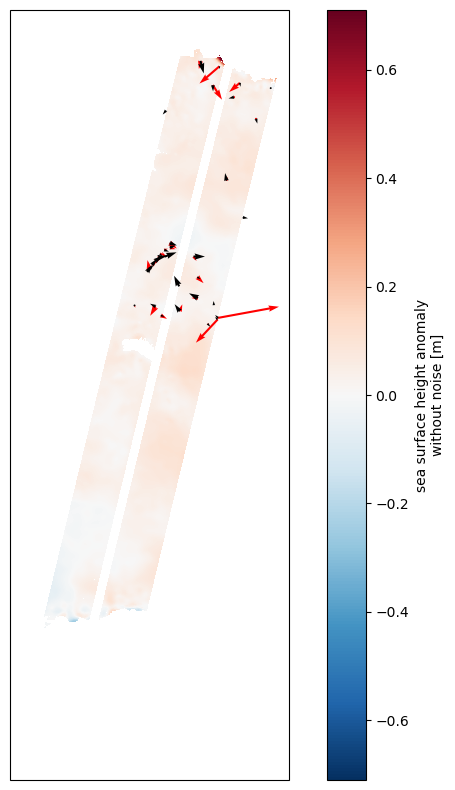

In [96]:
# df_ = df.loc[24]
swath = 3
cycle = 500

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(
    111, projection=ccrs.Orthographic(df_.longitude.iloc[0], df_.latitude.iloc[0])
)

dss = xr.open_dataset(
    dfs.where((dfs.pass_number == swath) & (dfs.cycle_number == cycle))
    .dropna()
    .file.values[0]
)
dss.duacs_ssha_karin_2_filtered.plot(
    x="longitude",
    y="latitude",
    ax=ax,
    transform=crs,
)
df_ = df.where((df.pass_number == swath) & (df.cycle_number == cycle)).dropna()
df__ = df_[(abs(df.duacs_speed_zonal) < 4) & (abs(df_.duacs_speed_meridional) < 4)]
ax.quiver(
    df__.longitude,
    df__.latitude,
    df__.duacs_speed_zonal,
    df__.duacs_speed_meridional,
    color="r",
    transform=crs,
    scale=10,
)
ax.quiver(
    df_.longitude,
    df_.latitude,
    df_.velocity_east,
    df_.velocity_north,
    transform=crs,
    scale=10,
)
ax.grid()

__________
# Test abusive values

In [104]:
id_pb = df[abs(df.duacs_speed_meridional) > 3].index.values

In [105]:
id_pb

array([   6,    9,   14,   18,   21,   29,   34,   35,   39,   56,   64,
         67,   68,   71,   76,   83,   88,   93,   94,  113,  116,  126,
        133,  147,  154,  158,  160,  164,  178,  180,  184,  191,  199,
        201,  209,  215,  219,  223,  229,  233,  238,  246,  252,  259,
        264,  267,  271,  278,  297,  305,  313,  321,  326,  336,  338,
        387,  389,  412,  414,  421,  428,  431,  439,  440,  443,  451,
        452,  454,  461,  464,  468,  473,  479,  491,  492,  502,  503,
        504,  505,  517,  524,  528,  534,  541,  550,  551,  569,  570,
        576,  599,  612,  618,  620,  625,  629,  630,  654,  660,  664,
        665,  672,  679,  683,  691,  693,  711,  713,  726,  754,  756,
        764,  765,  771,  831,  839,  851,  852,  857,  875,  879,  880,
        902,  935,  948,  949,  955,  962,  971,  972, 1013, 1015, 1016,
       1017, 1038, 1040, 1045, 1047, 1063, 1069, 1074, 1085, 1087, 1091,
       1092, 1097, 1105, 1119, 1120, 1126, 1132, 11

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: Runt

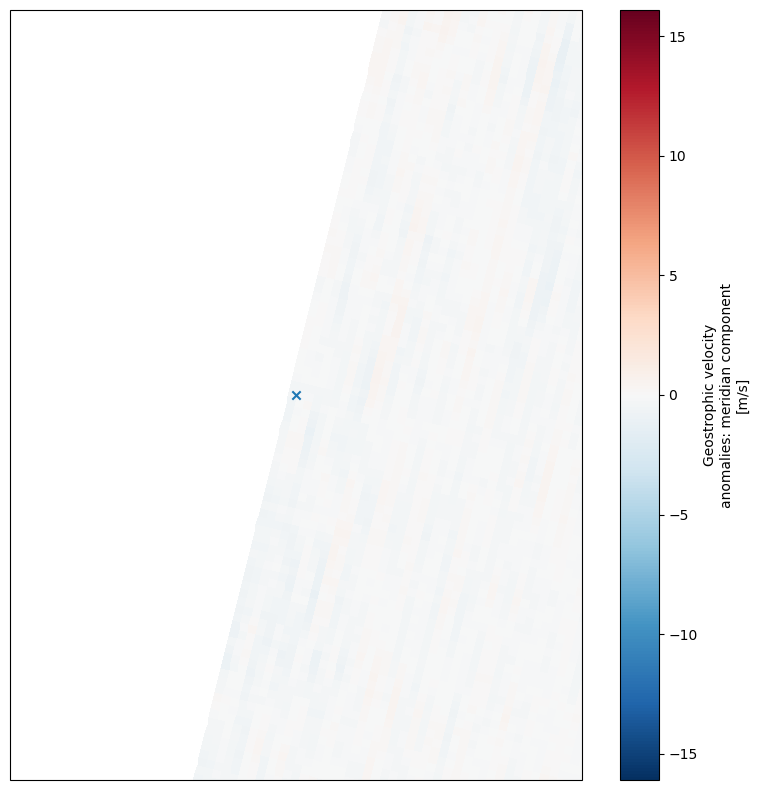

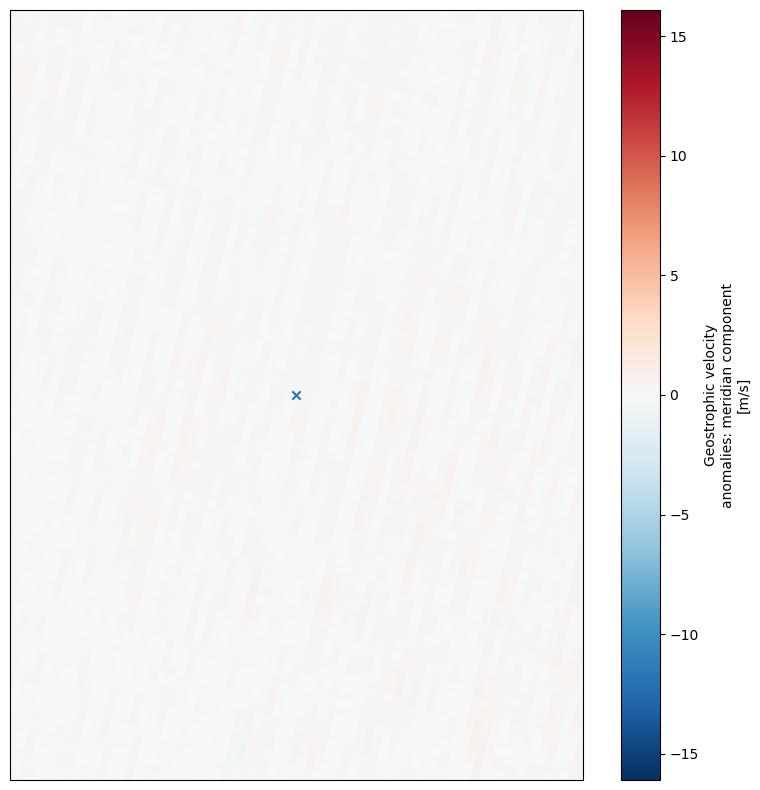

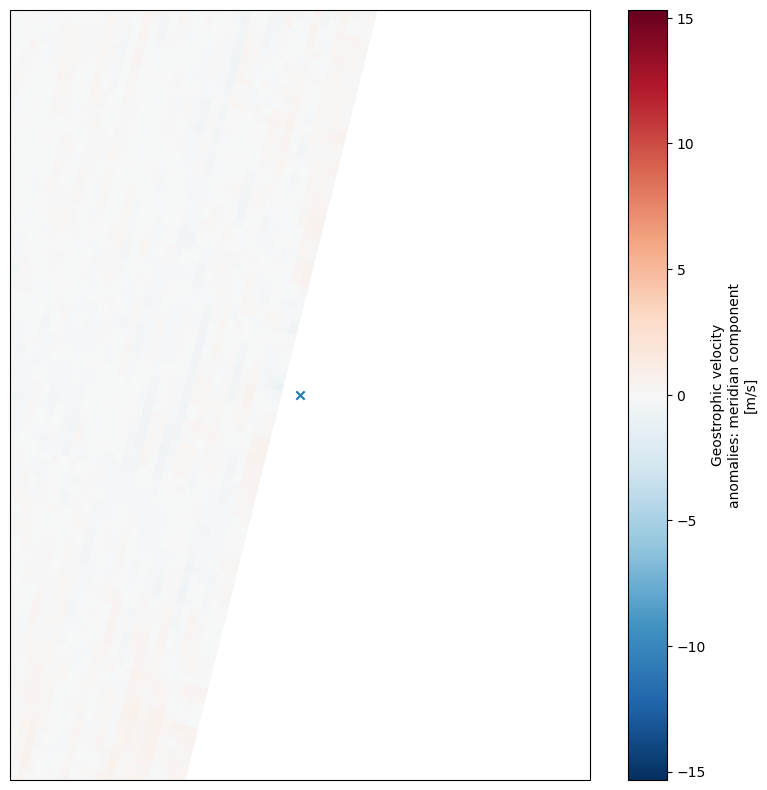

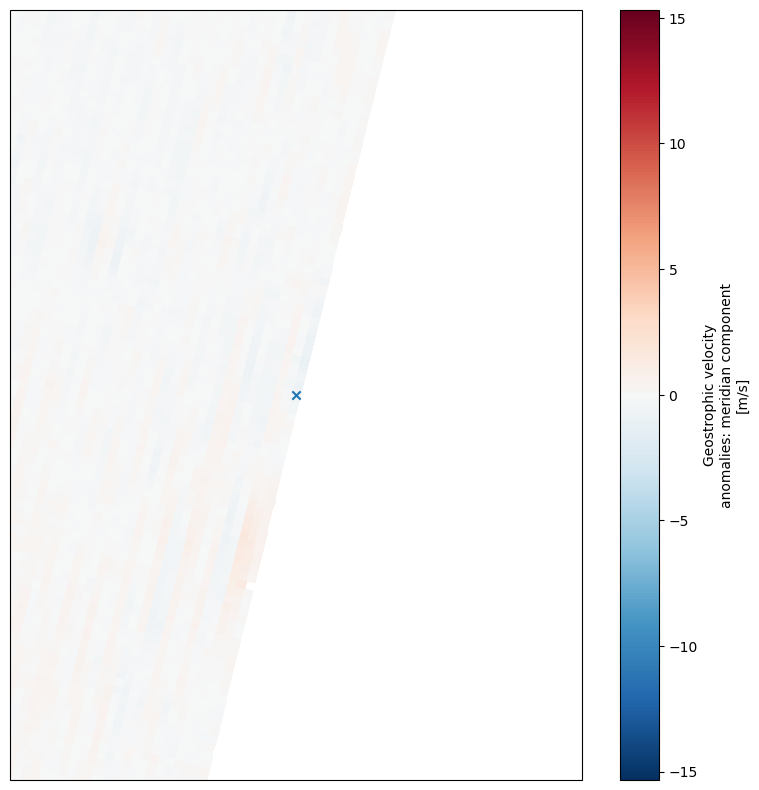

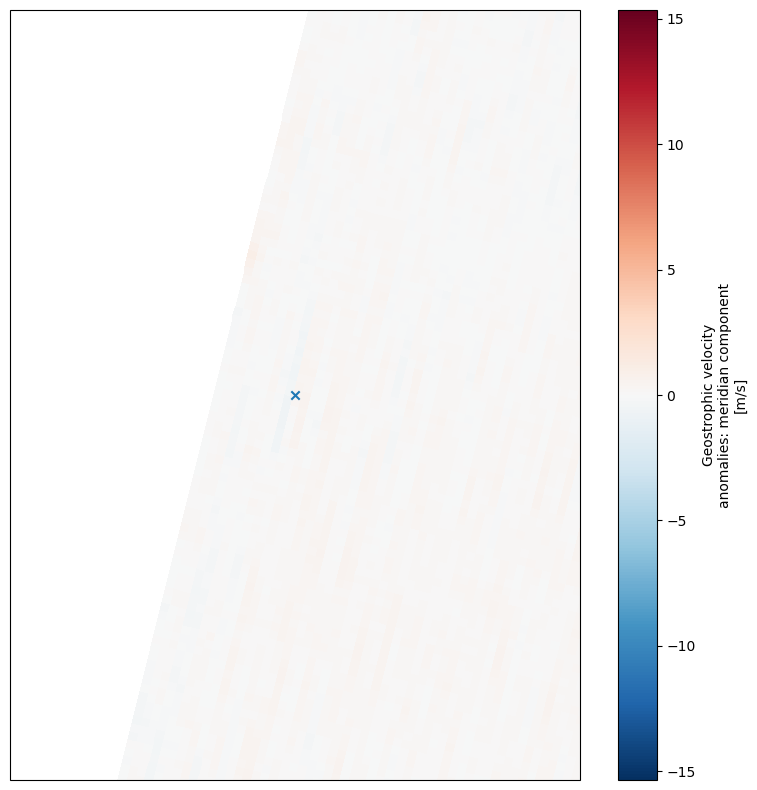

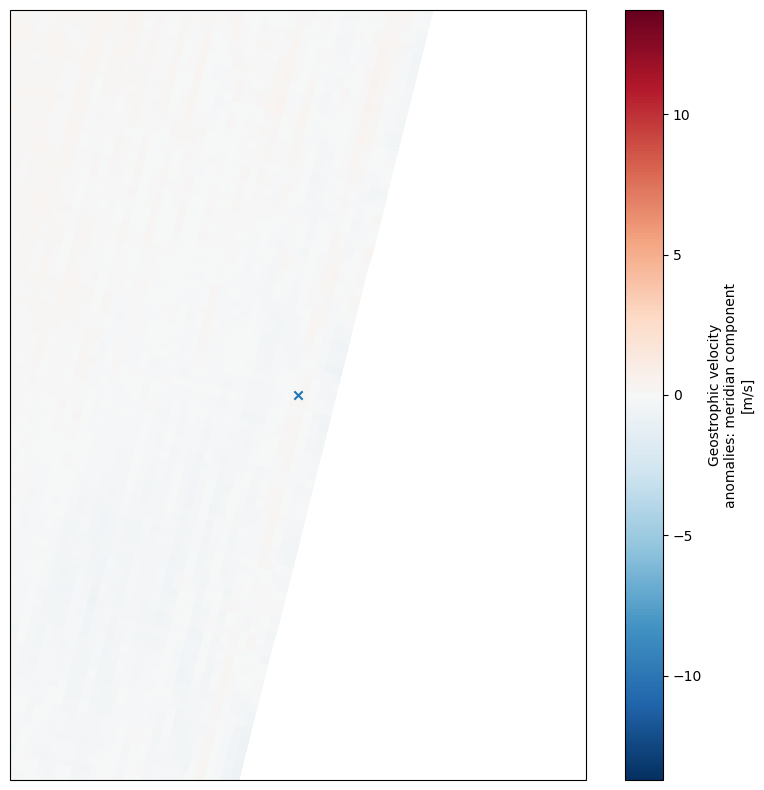

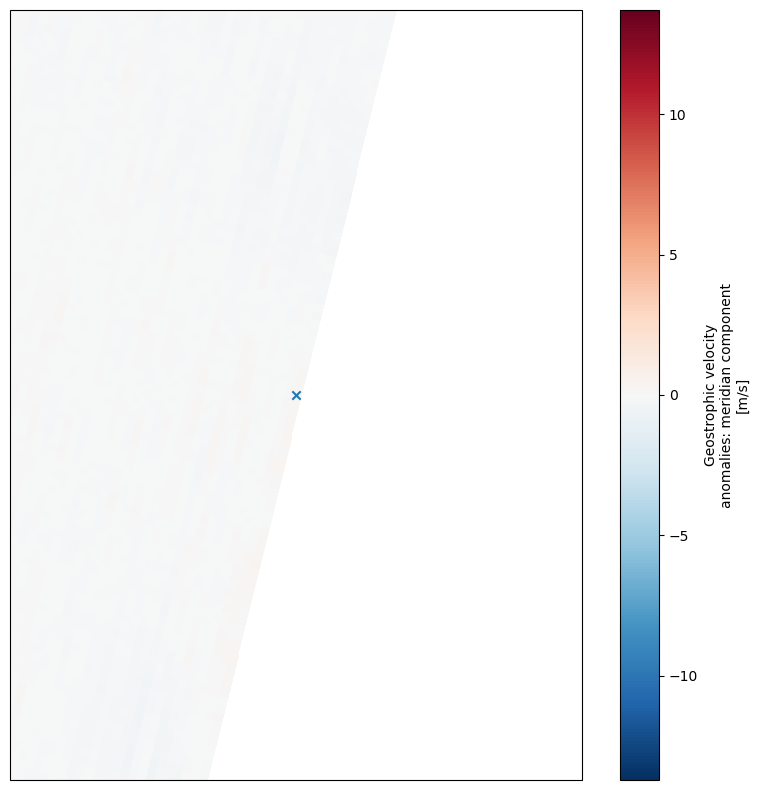

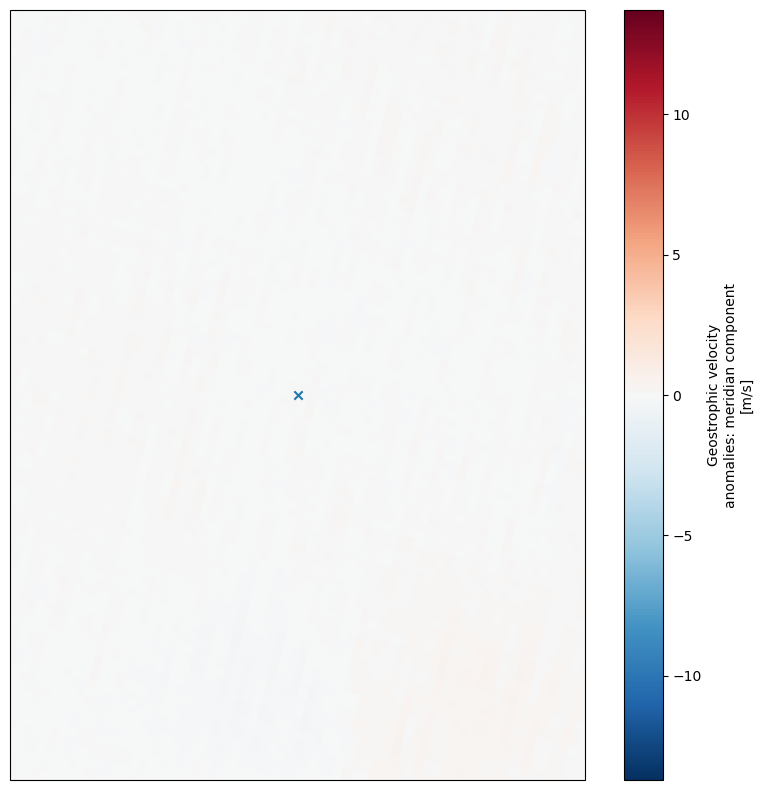

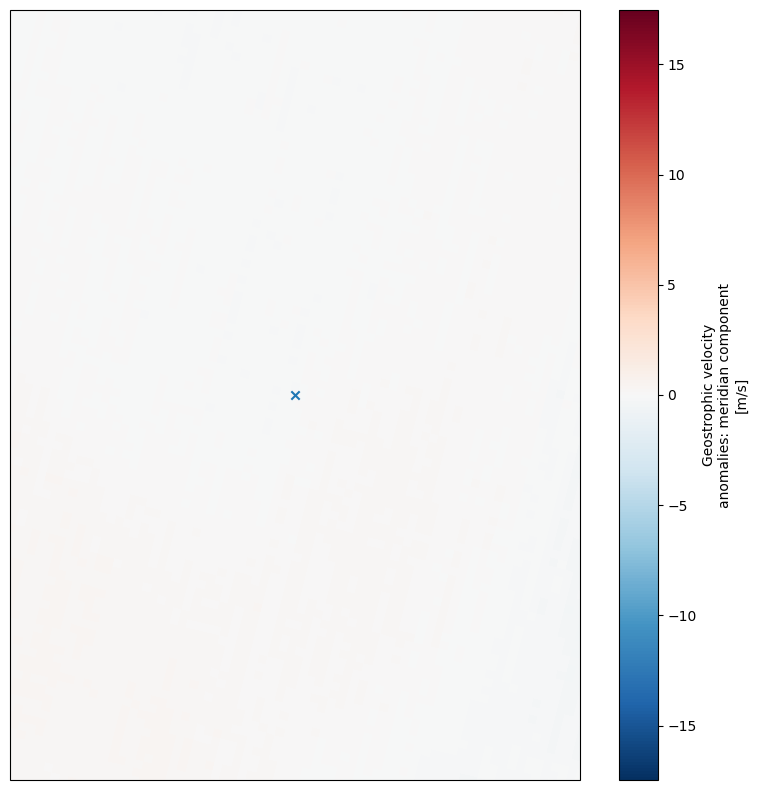

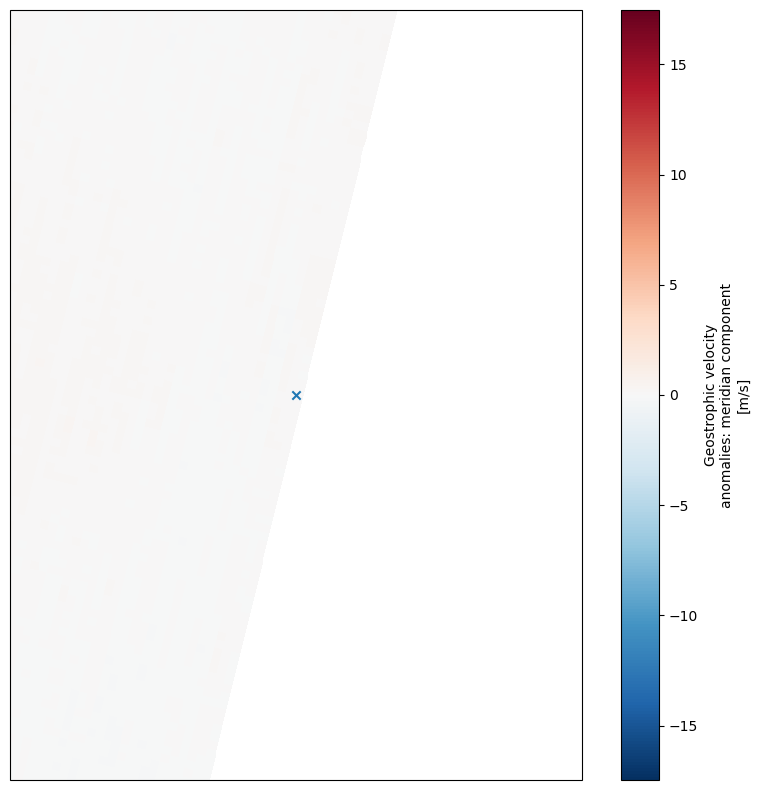

In [117]:
for i in id_pb[:10]:
    df_ = df.iloc[i]
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection=ccrs.Orthographic(df_.longitude, df_.latitude))
    dss = xr.open_dataset(
        dfs.where(
            (dfs.pass_number == df_.pass_number)
            & (dfs.cycle_number == df_.cycle_number)
        )
        .dropna()
        .file.values[0],
    )
    dss.duacs_speed_meridional.plot(
        x="longitude",
        y="latitude",
        ax=ax,
        transform=crs,
    )
    ax.scatter(
        df_.longitude,
        df_.latitude,
        marker="x",
        transform=crs,
    )
    dl = 0.1
    ax.set_extent(
        [df_.longitude - dl, df_.longitude + dl, df_.latitude - dl, df_.latitude + dl]
    )
    ax.grid()

_________
_________
_________
# Test functions

In [9]:
lond, latd = (5, 41)
xd, yd = lonlat2xy(
    dss0.attrs["lonc"],
    dss0.attrs["latc"],
    dss0.attrs["phi"],
    lond,
    latd,
    lon1=None,
    lat1=None,
)

In [10]:
xd, yd

(124478.10060965866, -24845.89273099015)

In [7]:
x, y = lonlat2xy(
    dss0.attrs["lonc"],
    dss0.attrs["latc"],
    dss0.attrs["phi"],
    dss0.lon,
    dss0.lat,
    lon1=None,
    lat1=None,
)
dss0["x"] = xr.DataArray(x, dims=["num_lines", "num_pixels"])
dss0["y"] = xr.DataArray(y, dims=["num_lines", "num_pixels"])
dss0 = dss0.set_coords(["x", "y"])

In [48]:
ggrad_var = [
    "duacs_ssha_karin_2_calibrated",
    "duacs_ssha_karin_2_filtered",
    "cvl_mean_dynamic_topography_cnes_cls_22",
    "cvl_mean_sea_surface_cnes_22_hybrid",
    "cvl_ocean_tide_fes_2022",
    "cvl_ssha_reference",
    "cvl_swh_model",
]

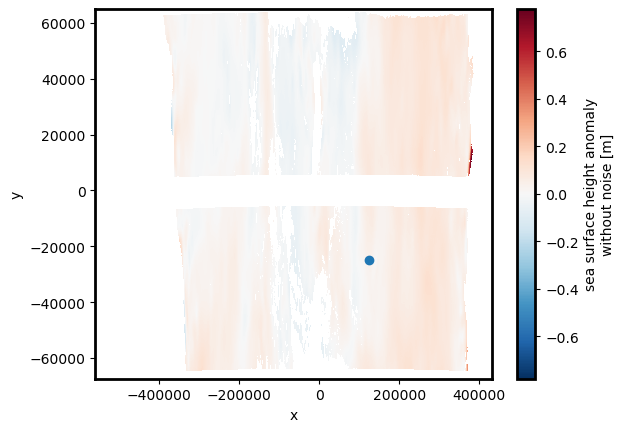

In [50]:
dss0.duacs_ssha_karin_2_filtered.plot(x="x", y="y")
plt.scatter(xd, yd)

In [129]:
dl = 2.5 * 1000
test_x = (dss0.x > xd - dl) & (dss0.x < xd + dl)
ds_ = dss0.where(test_x, drop=True)
test_y = (ds_.y > yd - dl) & (ds_.y < yd + dl)
ds_ = ds_.where(test_y, drop=True)
ds_

<xarray.Dataset> Size: 127kB
Dimensions:                                  (num_lines: 22, num_pixels: 20)
Coordinates:
    lat                                      (num_lines, num_pixels) float64 4kB ...
    lon                                      (num_lines, num_pixels) float64 4kB ...
    x                                        (num_lines, num_pixels) float64 4kB ...
    y                                        (num_lines, num_pixels) float64 4kB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/36)
    ancillary_surface_classification_flag    (num_lines, num_pixels) float32 2kB ...
    cross_track_distance                     (num_lines, num_pixels) float32 2kB ...
    cvl_dac                                  (num_lines, num_pixels) float64 4kB ...
    cvl_distance_to_coast                    (num_lines, num_pixels) float64 4kB ...
    cvl_flag_val                             (num_lines, num_pixels) float32 2kB ...
    cvl_ice_conc                             (num_lines, num_pixels) float64 4kB ...
    ...                                       ...
    pass_number                              (num_lines, num_pixels) float32 2kB ...
    sig0_karin_2                             (num_lines, num_pixels) float32 2kB ...
    ssh_karin_2_qual                         (num_lines, num_pixels) float64 4kB ...
    time                                     (num_lines, num_pixels) datetime64[ns] 4kB ...
    time_tai                                 (num_lines, num_pixels) datetime64[ns] 4kB ...
    version                                  (num_lines, num_pixels) object 4kB ...
Attributes:
    latc:     39.961324
    lonc:     4.3749
    phi:      76.80931729750102

In [86]:
box_x = np.arange(ds_.x.min(), ds_.x.max(), 125)
box_y = np.arange(ds_.y.min(), ds_.y.max(), 125)

In [123]:
ds_ = ds_.where(ds_.duacs_ssha_karin_2_filtered != np.nan, drop=True)

In [173]:
from scipy.interpolate import interp2d

Z = ds_.duacs_ssha_karin_2_filtered.values.ravel()
X = ds_.x.values.ravel()
Y = ds_.y.values.ravel()
_ds = xr.Dataset(data_vars=dict(x=(["a"], X), y=(["a"], Y), z=(["a"], Z)))
_ds = _ds.dropna("a")


f = interp2d(_ds.x, _ds.y, _ds.z)
Znew = f(box_x, box_y)

In [176]:
len(box_x), len(box_y)

(41, 39)

In [177]:
np.shape(Znew)

(39, 41)

In [179]:
da = xr.DataArray(Znew, coords={"x": box_x, "y": box_y}, dims=["y", "x"])

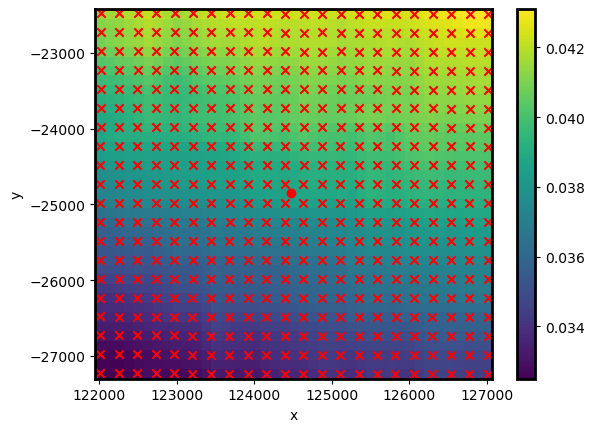

In [187]:
da.plot()
plt.scatter(X, Y, marker="x", c="r")
plt.scatter(xd, yd, c="r")

In [181]:
dax = da.differentiate("x")
day = da.differentiate("y")

In [184]:
dax.interp(x=xd, y=yd)

<xarray.DataArray ()> Size: 8B
array(8.71644815e-07)
Coordinates:
    x        float64 8B 1.245e+05
    y        float64 8B -2.485e+04